# Scaler를 사용해야 하는 이유
: 다차원의 변수 값을 비교분석하기 쉽게 만듬  
: 단위가 다르기 때문에 통일

# 결론: MinMaxScaler로 하자!

In [153]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

df = pd.read_csv('최종_분석데이터.csv',encoding='cp949')

df['행정동코드']=df['행정동코드'].astype(object)
df['법정동코드']=df['법정동코드'].astype(object)
df['grid']=df['grid'].astype(object)

df

Gulim


,grid,시도,시군구,행정동,행정동코드,법정동코드,법정동,대중교통,도시재생사업수,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
0,12,서울특별시,종로구,사직동,1101053,11110181,행촌동,32.851664,2,101.626016,0.000936,54159.49191,21,40,1.310124,2396871.578,0.0000,2396871.578
1,17,서울특별시,종로구,사직동,1101053,11110178,송월동,10007.456910,2,101.626016,0.000936,54159.49191,21,40,15.085963,3937642.857,0.0000,3937642.857
2,18,서울특별시,종로구,사직동,1101053,11110109,누상동,0.000000,2,101.626016,0.000936,54159.49191,21,40,0.000000,4099760.252,194850.0000,4051100.935
3,27,서울특별시,종로구,사직동,1101053,11110115,사직동,10000.721880,2,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
4,29,서울특별시,종로구,사직동,1101053,11110110,누하동,0.000000,2,101.626016,0.000936,54159.49191,21,40,0.000000,5636537.778,0.0000,5636537.778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30312,74995,서울특별시,강동구,강일동,1125075,11740110,강일동,7621.976731,0,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
30313,74996,서울특별시,강동구,강일동,1125075,11740110,강일동,9832.794677,0,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
30314,74997,서울특별시,강동구,강일동,1125075,11740110,강일동,10007.804010,0,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
30315,74998,서울특별시,강동구,강일동,1125075,11740110,강일동,10007.804010,0,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563


In [154]:
df.대중교통.describe()

count    30317.000000
mean      4888.278599
std       4455.645916
min          0.000000
25%          0.000000
50%       4442.261375
75%       9375.339010
max      20015.509760
Name: 대중교통, dtype: float64

- 변수별 이상치 제거

{'whiskers': [<matplotlib.lines.Line2D at 0x2031eb0c760>,
 'caps': [<matplotlib.lines.Line2D at 0x2031e5ac640>,
 'boxes': [<matplotlib.lines.Line2D at 0x2031bb7e0d0>,
 'medians': [<matplotlib.lines.Line2D at 0x2031e59feb0>,
 'fliers': [<matplotlib.lines.Line2D at 0x2031e25a880>,
 'means': []}

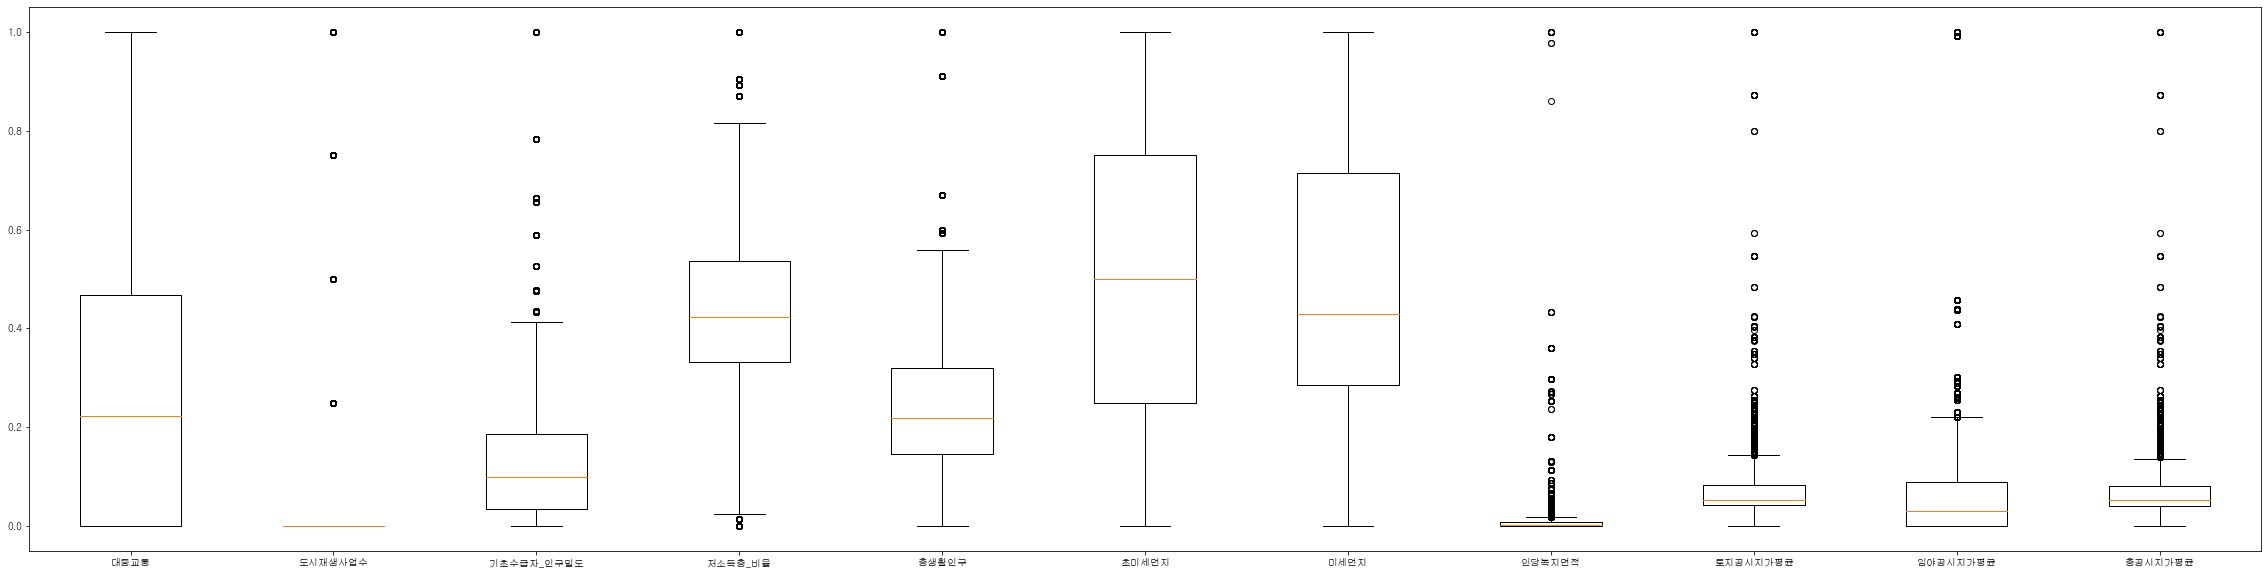

In [155]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,7:]) 

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df.iloc[:,7:].columns)

<기준>
- 도시재생사업수: 안뺌
- 대중교통은 2/3가 0이어서 이상치를 측정할 수 없었음. 그래서 0빼고 박스플랏 그려봤더니 이상치 없었음.
- 기초수급자 인구밀도,총생활인구수: 너무 높은 이상치 두 개 제거
- 저소득층: 이상치 전부 제거
- 인당녹지면적: 이상치 전부제거(인당녹지면적이 높은 곳은 후보지에서 제외)
- 공시지가: 이상치 전부제거 (공시지가가 너무 높은 곳은 후보지에서 제외)

### 이상치 제거

#### 1. 기초수급자_인구밀도

max이상치 행정동: ['사직동', '삼청동', '가회동', '종로1·2·3·4가동', '소공동', '회현동', '명동', '필동', '장충동', '광희동', '남영동', '증산동', '수색동', '상암동', '공항동', '방화2동', '방화3동','사당2동', '방배본동', '양재2동', '내곡동']

In [156]:
# 가장 큰 값 제거 - 2번
df = df[df.기초수급자_인구밀도 != df.기초수급자_인구밀도.max()]
df = df[df.기초수급자_인구밀도 != df.기초수급자_인구밀도.max()]

#### 2. 저소득층_비율
max이상치 행정동: ['화곡1동', '상도1동', '역삼1동', '길동']  
min이상치 행정동: ['소공동', '가락1동']

In [157]:
# 가장 큰 값 제거 - 1번
df = df[df.저소득층_비율 != df.저소득층_비율.max()]

In [159]:
import numpy as np

df['저소득층_비율'] = np.log1p(df['저소득층_비율'])
quantile_25 = np.quantile(df['저소득층_비율'], 0.25)
quantile_75 = np.quantile(df['저소득층_비율'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(df['저소득층_비율'] > minimum)]

#### 3. 총생활인구
max이상치 행정동: ['역삼1동']  
min이상치 행정동: ['삼청동', '창신3동', '신월6동', '반포본동', '둔촌1동']

In [161]:
df = df[df.총생활인구 != df.총생활인구.max()]
df = df[df.총생활인구 != df.총생활인구.max()]

#### 4. 인당녹지면적  
max = 4.310339892515737

In [163]:
import numpy as np

df['인당녹지면적'] = np.log1p(df['인당녹지면적'])
quantile_25 = np.quantile(df['인당녹지면적'], 0.25)
quantile_75 = np.quantile(df['인당녹지면적'],0.75)

IQR = quantile_75 - quantile_25

maximum = quantile_75 + 1.5 * IQR

df = df[(df['인당녹지면적'] <= maximum)]

# 공시지가

In [165]:
import numpy as np
df['총공시지가평균'] = np.log1p(df['총공시지가평균'])
quantile_25 = np.quantile(df['총공시지가평균'], 0.25)
quantile_75 = np.quantile(df['총공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['총공시지가평균']) & (df['총공시지가평균'] <= maximum)]

In [166]:
df['토지공시지가평균'] = np.log1p(df['토지공시지가평균'])
quantile_25 = np.quantile(df['토지공시지가평균'], 0.25)
quantile_75 = np.quantile(df['토지공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['토지공시지가평균']) & (df['토지공시지가평균'] <= maximum)]

In [167]:
df['임야공시지가평균'] = np.log1p(df['임야공시지가평균'])
quantile_25 = np.quantile(df['임야공시지가평균'], 0.25)
quantile_75 = np.quantile(df['임야공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['임야공시지가평균']) & (df['임야공시지가평균'] <= maximum)]

In [169]:
import numpy as np
df['총공시지가평균'] = np.log1p(df['총공시지가평균'])
quantile_25 = np.quantile(df['총공시지가평균'], 0.25)
quantile_75 = np.quantile(df['총공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['총공시지가평균']) & (df['총공시지가평균'] <= maximum)]

In [171]:
df.reset_index(drop=True,inplace=True)

# 결과

{'whiskers': [<matplotlib.lines.Line2D at 0x2031f09a5e0>,
 'caps': [<matplotlib.lines.Line2D at 0x2031f09ab80>,
 'boxes': [<matplotlib.lines.Line2D at 0x2031f09a310>,
 'medians': [<matplotlib.lines.Line2D at 0x2031f0a7160>,
 'fliers': [<matplotlib.lines.Line2D at 0x2031f0a7430>,
 'means': []}

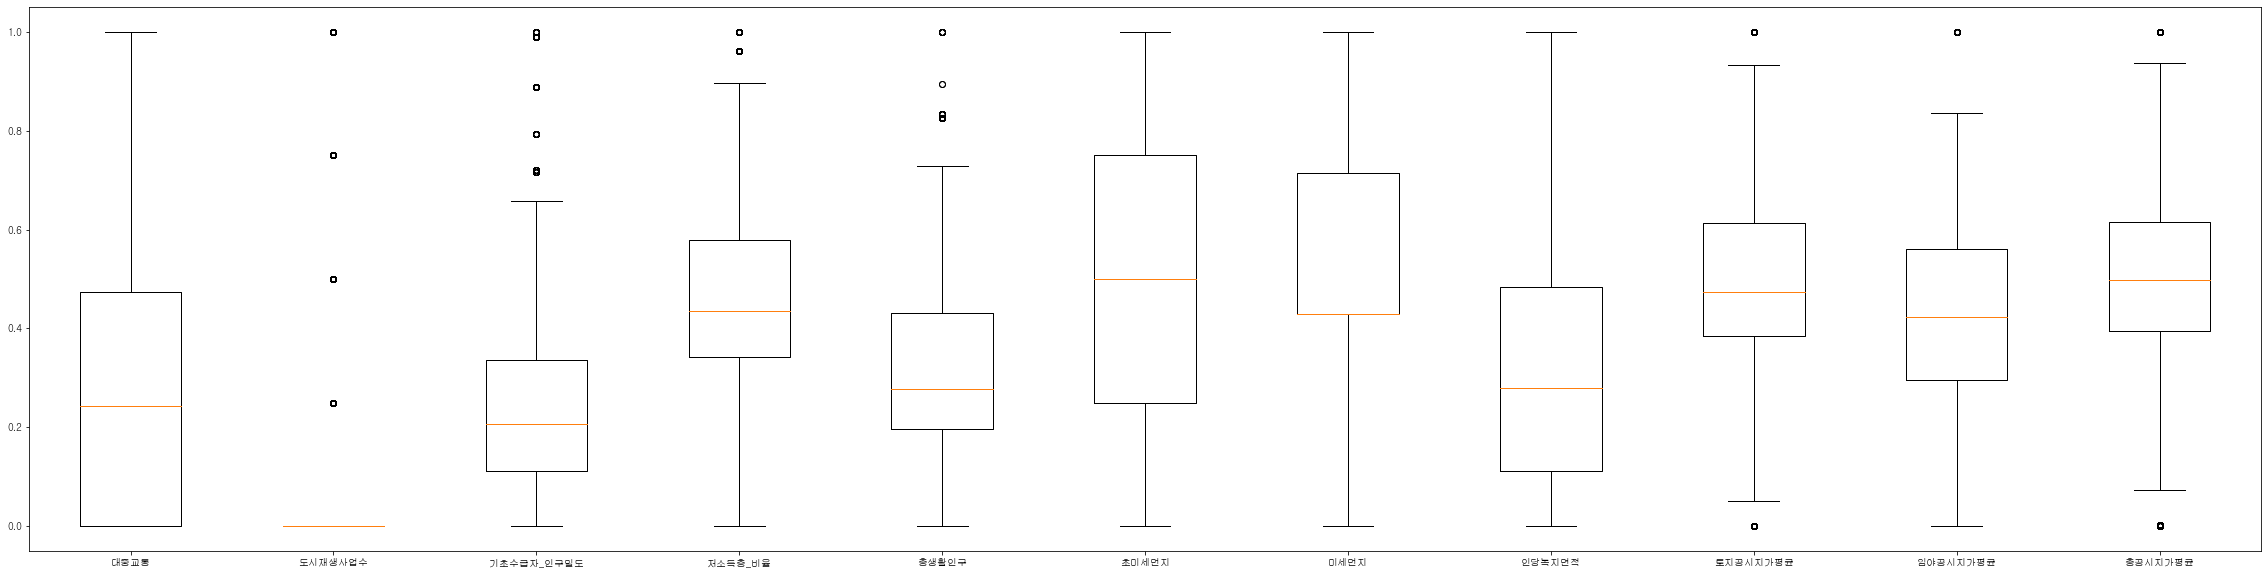

In [170]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,7:]) 

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df.iloc[:,7:].columns)

In [172]:
minMaxScaled_data

array([[0.        , 0.5       , 0.02161314, ..., 0.59616901, 0.17671609,
        0.61058656],
       [0.49964862, 0.5       , 0.02161314, ..., 0.53898426, 0.17719406,
        0.53915486],
       [0.09725165, 0.5       , 0.02161314, ..., 0.83528271, 0.67673019,
        0.84086299],
       ...,
       [0.        , 0.        , 0.22294946, ..., 0.37687773, 0.20140734,
        0.36834625],
       [0.        , 0.        , 0.22294946, ..., 0.37687773, 0.20140734,
        0.36834625],
       [0.        , 0.        , 0.22294946, ..., 0.37687773, 0.20140734,
        0.36834625]])

In [173]:
data_df = pd.DataFrame(minMaxScaled_data,columns = df.iloc[:,7:].columns.to_list())
data_df

,대중교통,도시재생사업수,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
0,0.000000,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.000000,0.596169,0.176716,0.610587
1,0.499649,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.933966,0.538984,0.177194,0.539155
2,0.097252,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.062430,0.835283,0.676730,0.840863
3,0.007157,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.933966,0.538984,0.177194,0.539155
4,0.263783,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.933966,0.538984,0.177194,0.539155
...,...,...,...,...,...,...,...,...,...,...,...
17932,0.000000,0.0,0.222949,0.510412,0.655698,0.75,0.571429,0.655246,0.376878,0.201407,0.368346
17933,0.494424,0.0,0.222949,0.510412,0.655698,0.75,0.571429,0.655246,0.376878,0.201407,0.368346
17934,0.000000,0.0,0.222949,0.510412,0.655698,0.75,0.571429,0.655246,0.376878,0.201407,0.368346
17935,0.000000,0.0,0.222949,0.510412,0.655698,0.75,0.571429,0.655246,0.376878,0.201407,0.368346


In [174]:
df

,grid,시도,시군구,행정동,행정동코드,법정동코드,법정동,대중교통,도시재생사업수,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
0,18,서울특별시,종로구,사직동,1101053,11110109,누상동,0.000000,2,101.626016,0.000935,54159.49191,21,40,0.000000,15.226439,12.179990,2.785906
1,27,서울특별시,종로구,사직동,1101053,11110115,사직동,10000.721880,2,101.626016,0.000935,54159.49191,21,40,3.953612,15.144784,12.182390,2.779410
2,32,서울특별시,종로구,사직동,1101053,11110113,필운동,1946.541338,2,101.626016,0.000935,54159.49191,21,40,0.264276,15.567876,14.690539,2.806847
3,39,서울특별시,종로구,사직동,1101053,11110115,사직동,143.244974,2,101.626016,0.000935,54159.49191,21,40,3.953612,15.144784,12.182390,2.779410
4,40,서울특별시,종로구,사직동,1101053,11110115,사직동,5279.750361,2,101.626016,0.000935,54159.49191,21,40,3.953612,15.144784,12.182390,2.779410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17932,74846,서울특별시,강동구,강일동,1125075,11740102,고덕동,0.000000,0,1032.258065,0.002857,98420.37476,21,39,2.773751,14.913308,12.303964,2.763877
17933,74847,서울특별시,강동구,강일동,1125075,11740102,고덕동,9896.143394,0,1032.258065,0.002857,98420.37476,21,39,2.773751,14.913308,12.303964,2.763877
17934,74848,서울특별시,강동구,강일동,1125075,11740102,고덕동,0.000000,0,1032.258065,0.002857,98420.37476,21,39,2.773751,14.913308,12.303964,2.763877
17935,74849,서울특별시,강동구,강일동,1125075,11740102,고덕동,0.000000,0,1032.258065,0.002857,98420.37476,21,39,2.773751,14.913308,12.303964,2.763877


In [175]:
정제데이터 = pd.concat([df.iloc[:,:7],data_df], axis=1)

In [176]:
정제데이터

,grid,시도,시군구,행정동,행정동코드,법정동코드,법정동,대중교통,도시재생사업수,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
0,18,서울특별시,종로구,사직동,1101053,11110109,누상동,0.000000,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.000000,0.596169,0.176716,0.610587
1,27,서울특별시,종로구,사직동,1101053,11110115,사직동,0.499649,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.933966,0.538984,0.177194,0.539155
2,32,서울특별시,종로구,사직동,1101053,11110113,필운동,0.097252,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.062430,0.835283,0.676730,0.840863
3,39,서울특별시,종로구,사직동,1101053,11110115,사직동,0.007157,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.933966,0.538984,0.177194,0.539155
4,40,서울특별시,종로구,사직동,1101053,11110115,사직동,0.263783,0.5,0.021613,0.118804,0.335546,0.75,0.714286,0.933966,0.538984,0.177194,0.539155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17932,74846,서울특별시,강동구,강일동,1125075,11740102,고덕동,0.000000,0.0,0.222949,0.510412,0.655698,0.75,0.571429,0.655246,0.376878,0.201407,0.368346
17933,74847,서울특별시,강동구,강일동,1125075,11740102,고덕동,0.494424,0.0,0.222949,0.510412,0.655698,0.75,0.571429,0.655246,0.376878,0.201407,0.368346
17934,74848,서울특별시,강동구,강일동,1125075,11740102,고덕동,0.000000,0.0,0.222949,0.510412,0.655698,0.75,0.571429,0.655246,0.376878,0.201407,0.368346
17935,74849,서울특별시,강동구,강일동,1125075,11740102,고덕동,0.000000,0.0,0.222949,0.510412,0.655698,0.75,0.571429,0.655246,0.376878,0.201407,0.368346


In [177]:
정제데이터.to_csv('또 다른 스케일링.csv',encoding='cp949',index=False)